In [1]:
print("NBA Project Starts Here")

NBA Project Starts Here


In [2]:
import pandas as pd


In [3]:
df = pd.read_csv("games.csv")

In [12]:
#Some of the features we want to use have missing values, so we will drop those rows for now.
print(df[['FG_PCT_home', 'FT_PCT_home', 'AST_home', 'REB_home', 'PTS_home']].isnull().sum())
print(f'Rows before: {len(df)}')
features = ['FG_PCT_home', 'FT_PCT_home', 'AST_home', 'REB_home', 'PTS_home']
df = df.dropna(subset=features)
print(f'Rows after: {len(df)}')

FG_PCT_home    0
FT_PCT_home    0
AST_home       0
REB_home       0
PTS_home       0
dtype: int64
Rows before: 26552
Rows after: 26552


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df[['FG_PCT_home', 'FT_PCT_home', 'AST_home', 'REB_home', 'PTS_home']]
y = df['HOME_TEAM_WINS']

#Split the data into training and testing sets
#80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Scale the features
scaler =StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Logistic Regression Model
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
#Evaluate the models
from sklearn.metrics import classification_report, confusion_matrix
predictions = log_model.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.73      0.68      0.70      2184
           1       0.79      0.83      0.81      3127

    accuracy                           0.77      5311
   macro avg       0.76      0.75      0.76      5311
weighted avg       0.76      0.77      0.76      5311



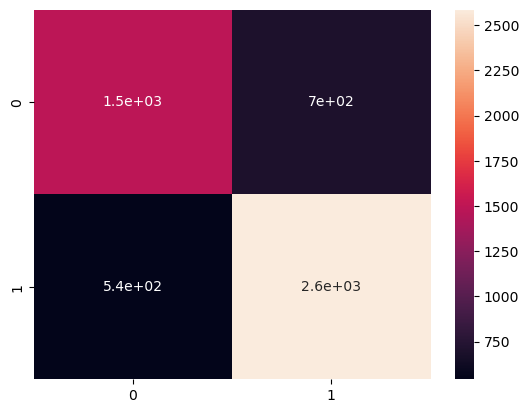

In [ ]:
#Visualisaton of confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True)
plt.show()

In [ ]:
#Correlation Matrix
cols_to_correlate = ['FG_PCT_home', 'FT_PCT_home', 'AST_home', 'REB_home', 'PTS_home', 'HOME_TEAM_WINS']
corr_matrix = df[cols_to_correlate].corr()
print(corr_matrix)

                FG_PCT_home  FT_PCT_home  AST_home  REB_home  PTS_home  \
FG_PCT_home        1.000000     0.021179  0.550769 -0.188416  0.662165   
FT_PCT_home        0.021179     1.000000  0.022611 -0.051505  0.187056   
AST_home           0.550769     0.022611  1.000000  0.066184  0.605409   
REB_home          -0.188416    -0.051505  0.066184  1.000000  0.162274   
PTS_home           0.662165     0.187056  0.605409  0.162274  1.000000   
HOME_TEAM_WINS     0.432700     0.093394  0.301750  0.245884  0.395810   

                HOME_TEAM_WINS  
FG_PCT_home           0.432700  
FT_PCT_home           0.093394  
AST_home              0.301750  
REB_home              0.245884  
PTS_home              0.395810  
HOME_TEAM_WINS        1.000000  


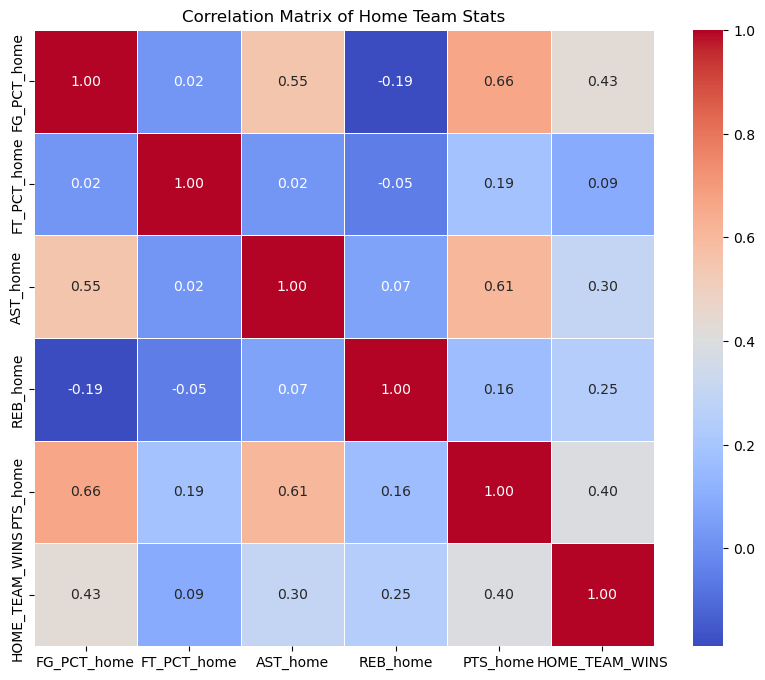

In [ ]:
#Visualisation of correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Home Team Stats")
plt.show()